# Prédiction des ventes hebdomadaires de Walmart

## Contexte métier
Walmart souhaite estimer les **ventes hebdomadaires** de ses magasins à partir d'informations magasin, calendaires et macroéconomiques.  
Un tel modèle peut aider à mieux comprendre les facteurs associés au niveau des ventes et à mieux préparer certaines décisions opérationnelles ou marketing.

## Objectif du notebook
L'objectif est de construire un modèle de régression capable de prédire **`Weekly_Sales`** avec une bonne précision, tout en restant :
- cohérent avec le brief ;
- fidèle aux méthodes vues en cours ;
- lisible et interprétable.

## Démarche retenue
Le notebook suit une progression simple et défendable :

1. audit initial du jeu de données ;
2. nettoyage avec **pandas** ;
3. analyse exploratoire ;
4. preprocessing avec **scikit-learn** ;
5. modèle de base avec **LinearRegression** ;
6. réduction de l'overfitting avec **Ridge** et **Lasso** ;
7. comparaison des résultats, interprétation et conclusion.

## Périmètre couvert
Conformément au sujet, le notebook :
- supprime les lignes où **`Weekly_Sales`** est manquant ;
- extrait des variables numériques à partir de **`Date`** ;
- retire les valeurs extrêmes selon la règle des **3 sigmas** ;
- traite **`Store`** et **`Holiday_Flag`** comme variables catégorielles ;
- entraîne une **régression linéaire** de base ;
- compare cette baseline à des modèles **régularisés**.


In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


In [2]:

DATA_PATH = "data/Walmart_Store_sales.csv"

df_raw = pd.read_csv(DATA_PATH)

print(f"Dimensions brutes du jeu de données : {df_raw.shape}")
display(df_raw.head())


Dimensions brutes du jeu de données : (150, 8)


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,6.00,18-02-2011,"1,572,117.54",NaN,59.61,3.04,214.78,6.86
1,13.00,25-03-2011,"1,807,545.43",0.00,42.38,3.44,128.62,7.47
2,17.00,27-07-2012,NaN,0.00,NaN,NaN,130.72,5.94
3,11.00,NaN,"1,244,390.03",0.00,84.57,NaN,214.56,7.35
4,6.00,28-05-2010,"1,644,470.66",0.00,78.89,2.76,212.41,7.09


## 1. Audit initial du jeu de données

In [3]:

summary = pd.DataFrame({
    "type": df_raw.dtypes.astype(str),
    "valeurs_manquantes": df_raw.isna().sum(),
    "pct_manquant": (df_raw.isna().mean() * 100).round(1),
    "valeurs_uniques": df_raw.nunique(dropna=True)
}).sort_values("valeurs_manquantes", ascending=False)

display(summary)


,type,valeurs_manquantes,pct_manquant,valeurs_uniques
Date,object,18,12.00,85
Temperature,float64,18,12.00,130
Unemployment,float64,15,10.00,104
Weekly_Sales,float64,14,9.30,136
Fuel_Price,float64,14,9.30,120
Holiday_Flag,float64,12,8.00,2
CPI,float64,12,8.00,135
Store,float64,0,0.00,20


Nombre de doublons : 0
Lignes avec cible Weekly_Sales manquante : 14


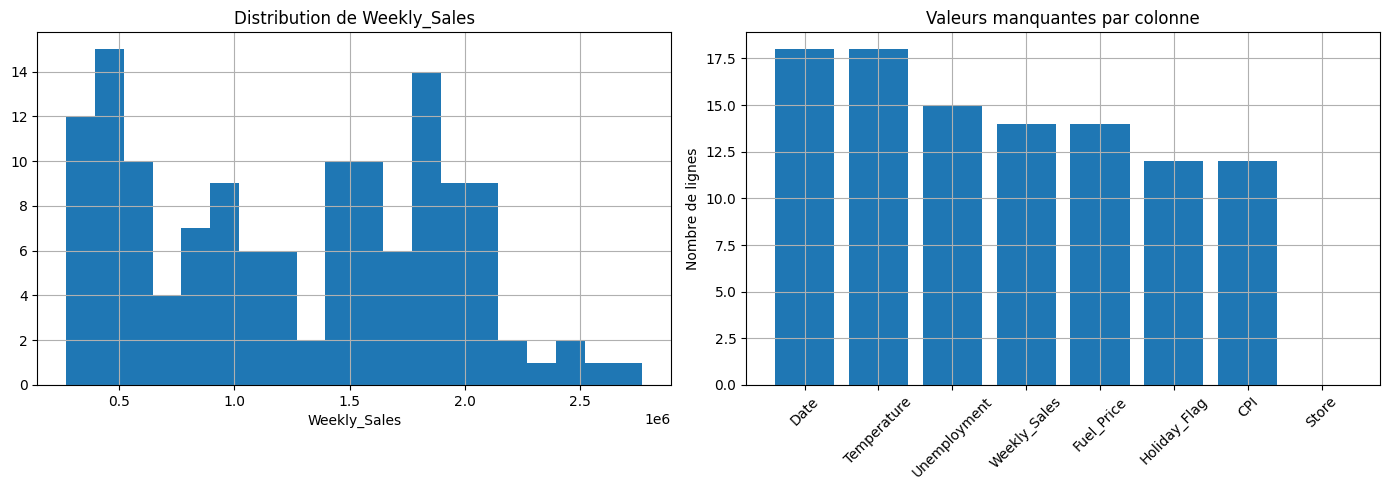

In [4]:

print("Nombre de doublons :", df_raw.duplicated().sum())
print("Lignes avec cible Weekly_Sales manquante :", int(df_raw["Weekly_Sales"].isna().sum()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_raw["Weekly_Sales"].dropna(), bins=20)
axes[0].set_title("Distribution de Weekly_Sales")
axes[0].set_xlabel("Weekly_Sales")

missing_counts = df_raw.isna().sum().sort_values(ascending=False)
axes[1].bar(missing_counts.index, missing_counts.values)
axes[1].set_title("Valeurs manquantes par colonne")
axes[1].set_ylabel("Nombre de lignes")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


### Principaux constats sur le jeu de données brut
- Le dataset est **petit** (**150 lignes**), donc chaque choix de preprocessing a un impact visible.
- La cible **`Weekly_Sales`** contient des valeurs manquantes. Conformément au brief, ces lignes doivent être **supprimées** et non imputées.
- Plusieurs variables explicatives contiennent également des valeurs manquantes ; elles seront gérées ensuite dans le pipeline de preprocessing.
- `Store` et `Holiday_Flag` doivent être traitées comme des variables catégorielles, exactement comme indiqué dans le sujet.
- Compte tenu de la taille du jeu de données et du cadrage pédagogique, une approche fondée sur la **régression linéaire** et la **régularisation** est pertinente et suffisante.


## 2. Nettoyage du dataset exactement comme demandé

In [5]:

df = df_raw.copy()

# Étape 1 — supprimer les lignes où la cible est manquante
rows_raw = len(df)
df = df.dropna(subset=["Weekly_Sales"]).copy()
rows_after_target_drop = len(df)

# Étape 2 — créer des variables numériques à partir de Date
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y", errors="coerce")
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek

# Étape 3 — retirer les valeurs extrêmes selon la règle demandée des 3 sigmas
outlier_cols = ["Temperature", "Fuel_Price", "CPI", "Unemployment"]
outlier_rows_removed = []

for col in outlier_cols:
    mean_col = df[col].mean(skipna=True)
    std_col = df[col].std(skipna=True)
    lower_bound = mean_col - 3 * std_col
    upper_bound = mean_col + 3 * std_col

    mask_outlier = (~df[col].between(lower_bound, upper_bound)) & df[col].notna()
    removed = int(mask_outlier.sum())

    outlier_rows_removed.append({
        "colonne": col,
        "moyenne": round(mean_col, 3),
        "ecart_type": round(std_col, 3),
        "borne_basse": round(lower_bound, 3),
        "borne_haute": round(upper_bound, 3),
        "lignes_retires": removed
    })

    df = df[(df[col].between(lower_bound, upper_bound)) | (df[col].isna())].copy()

rows_after_outliers = len(df)

cleaning_report = pd.DataFrame({
    "etape": [
        "Jeu de données brut",
        "Après suppression de la cible manquante",
        "Après filtrage 3 sigmas"
    ],
    "nombre_de_lignes": [
        rows_raw,
        rows_after_target_drop,
        rows_after_outliers
    ]
})

display(cleaning_report)
display(pd.DataFrame(outlier_rows_removed))


,etape,nombre_de_lignes
0,Jeu de données brut,150
1,Après suppression de la cible manquante,136
2,Après filtrage 3 sigmas,131


,colonne,moyenne,ecart_type,borne_basse,borne_haute,lignes_retires
0,Temperature,60.85,18.51,5.31,116.40,0
1,Fuel_Price,3.32,0.48,1.88,4.76,0
2,CPI,178.09,40.24,57.36,298.82,0
3,Unemployment,7.67,1.62,2.81,12.52,5


In [6]:

missing_after_cleaning = pd.DataFrame({
    "valeurs_manquantes": df.isna().sum(),
    "pct_manquant": (df.isna().mean() * 100).round(1)
}).sort_values("valeurs_manquantes", ascending=False)

display(missing_after_cleaning)

weekday_map = {"Monday": "Lundi", "Tuesday": "Mardi", "Wednesday": "Mercredi", "Thursday": "Jeudi", "Friday": "Vendredi", "Saturday": "Samedi", "Sunday": "Dimanche"}
weekday_counts = df["Date"].dt.day_name().map(weekday_map).fillna("Manquant").value_counts(dropna=False).rename_axis("jour_semaine").reset_index(name="nombre")
display(weekday_counts)


,valeurs_manquantes,pct_manquant
Date,18,13.70
Month,18,13.70
Day,18,13.70
DayOfWeek,18,13.70
Year,18,13.70
Unemployment,14,10.70
Temperature,14,10.70
Fuel_Price,12,9.20
Holiday_Flag,11,8.40
CPI,11,8.40


,jour_semaine,nombre
0,Vendredi,113
1,Manquant,18


### Enseignements du nettoyage
- La suppression des lignes dont la cible est manquante fait passer le dataset de **150** à **136** lignes.
- Le filtrage demandé par la règle des **3 sigmas** retire **5 lignes supplémentaires**, toutes liées à **`Unemployment`**.
- Après nettoyage, le dataset de travail contient **131 lignes**.
- Point important pour l'interprétation : parmi les dates valides, presque toutes les observations tombent un **vendredi**.  
  `DayOfWeek` est donc bien créé, conformément au sujet, mais il est logique qu'il apporte ici **très peu d'information**.


## 3. Analyse exploratoire des données (EDA)

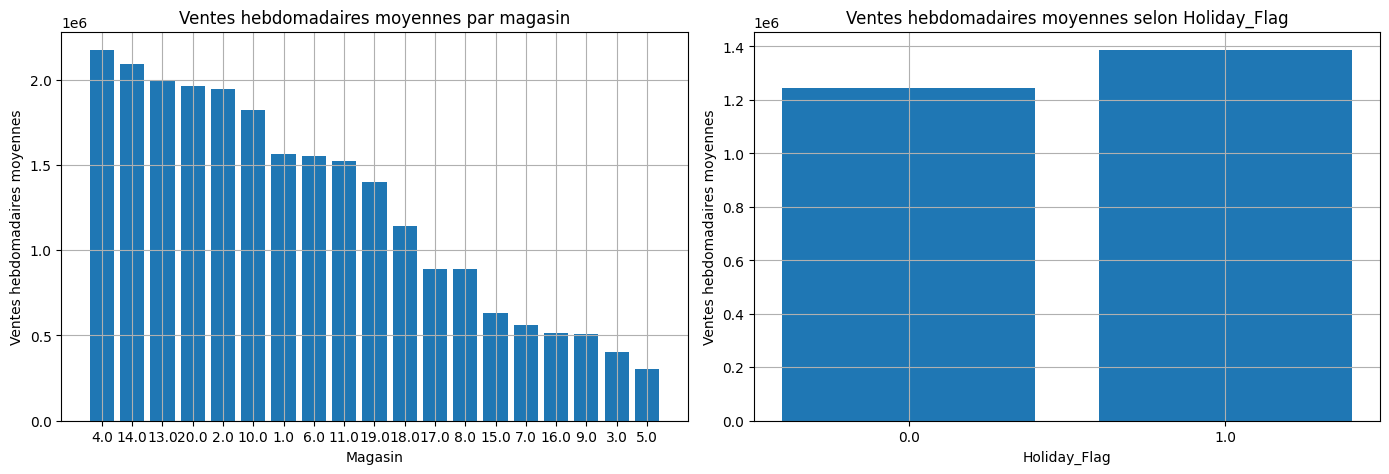

,nombre_obs,ventes_moyennes,ventes_medianes
Holiday_Flag,,,
0.00,112,"1,246,015.84","1,255,685.02"
1.00,8,"1,386,762.50","1,651,862.39"


In [7]:

eda_df = df.copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

store_means = eda_df.groupby("Store")["Weekly_Sales"].mean().sort_values(ascending=False)
axes[0].bar(store_means.index.astype(str), store_means.values)
axes[0].set_title("Ventes hebdomadaires moyennes par magasin")
axes[0].set_xlabel("Magasin")
axes[0].set_ylabel("Ventes hebdomadaires moyennes")

holiday_stats = eda_df.groupby("Holiday_Flag")["Weekly_Sales"].mean()
axes[1].bar(holiday_stats.index.astype(str), holiday_stats.values)
axes[1].set_title("Ventes hebdomadaires moyennes selon Holiday_Flag")
axes[1].set_xlabel("Holiday_Flag")
axes[1].set_ylabel("Ventes hebdomadaires moyennes")

plt.tight_layout()
plt.show()

display(
    eda_df.groupby("Holiday_Flag")["Weekly_Sales"].agg(["count", "mean", "median"]).rename(
        columns={"count": "nombre_obs", "mean": "ventes_moyennes", "median": "ventes_medianes"}
    )
)


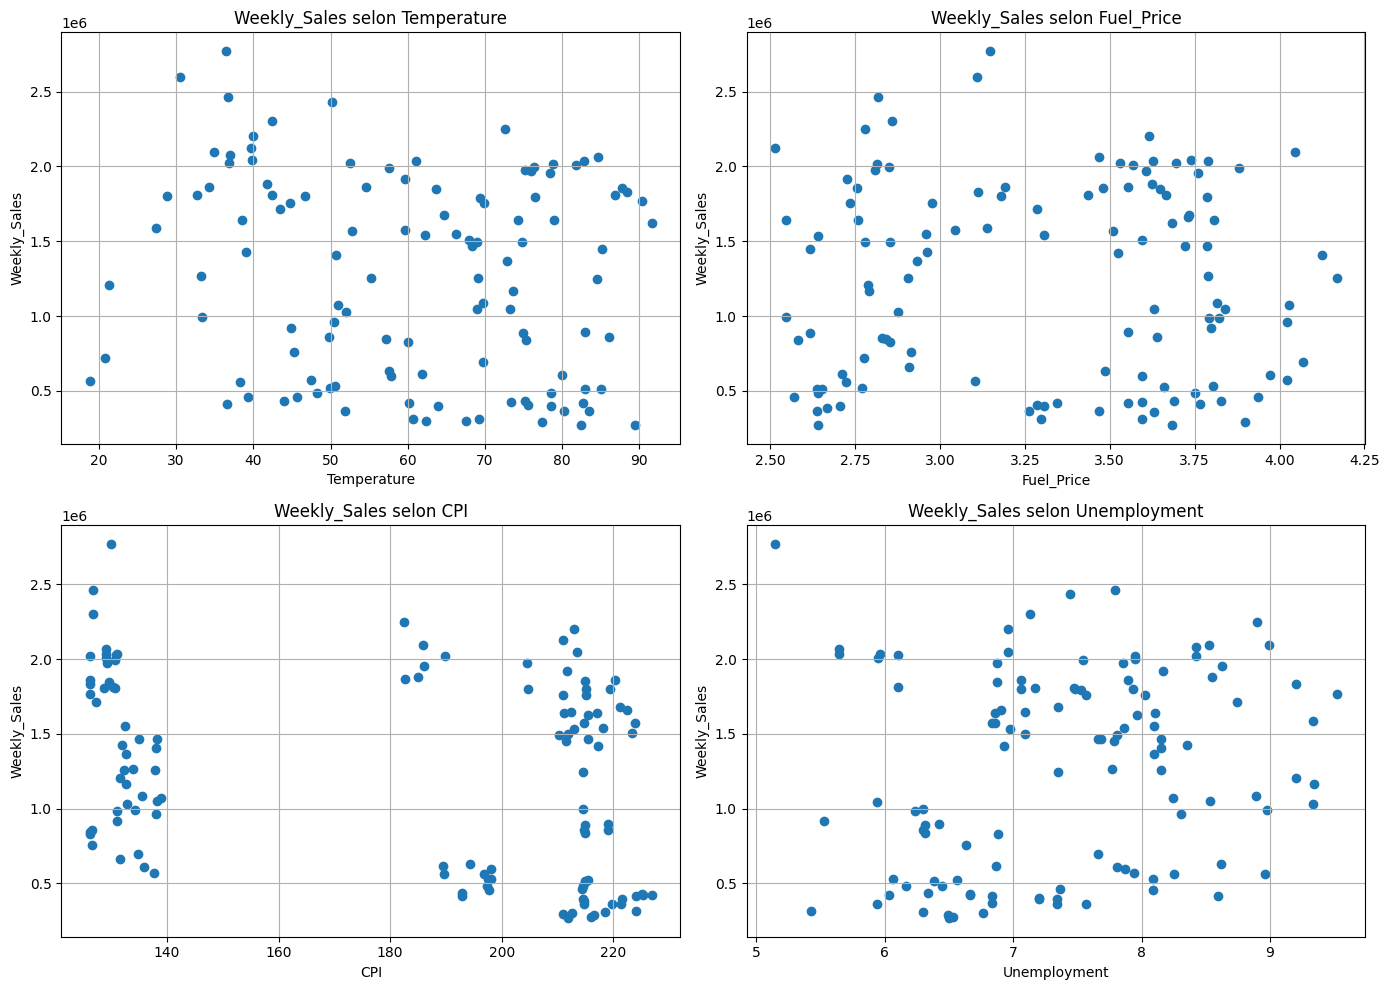

In [8]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(eda_df["Temperature"], eda_df["Weekly_Sales"])
axes[0, 0].set_title("Weekly_Sales selon Temperature")
axes[0, 0].set_xlabel("Temperature")
axes[0, 0].set_ylabel("Weekly_Sales")

axes[0, 1].scatter(eda_df["Fuel_Price"], eda_df["Weekly_Sales"])
axes[0, 1].set_title("Weekly_Sales selon Fuel_Price")
axes[0, 1].set_xlabel("Fuel_Price")
axes[0, 1].set_ylabel("Weekly_Sales")

axes[1, 0].scatter(eda_df["CPI"], eda_df["Weekly_Sales"])
axes[1, 0].set_title("Weekly_Sales selon CPI")
axes[1, 0].set_xlabel("CPI")
axes[1, 0].set_ylabel("Weekly_Sales")

axes[1, 1].scatter(eda_df["Unemployment"], eda_df["Weekly_Sales"])
axes[1, 1].set_title("Weekly_Sales selon Unemployment")
axes[1, 1].set_xlabel("Unemployment")
axes[1, 1].set_ylabel("Weekly_Sales")

plt.tight_layout()
plt.show()


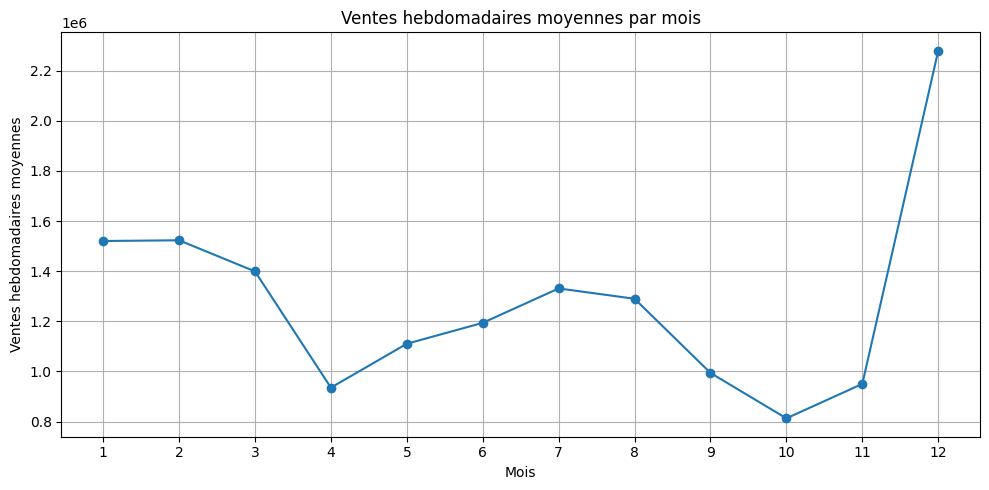

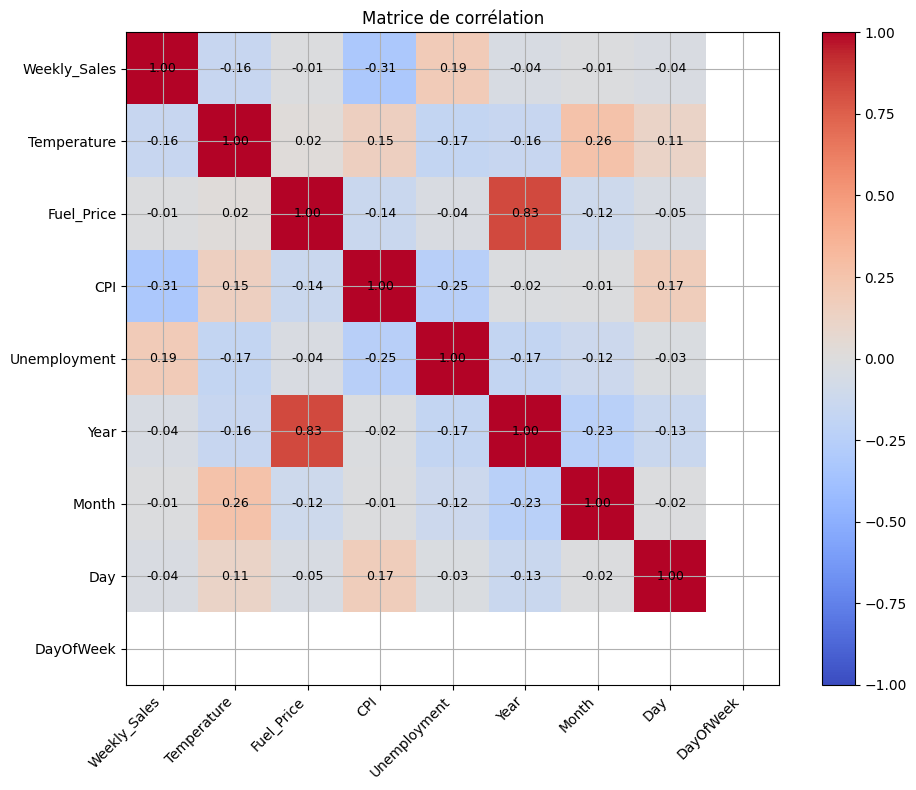

,correlation_avec_cible
Weekly_Sales,1.00
Unemployment,0.19
Fuel_Price,-0.01
Month,-0.01
Day,-0.04
Year,-0.04
Temperature,-0.16
CPI,-0.31
DayOfWeek,NaN


In [9]:

monthly_sales = (
    eda_df.groupby("Month")["Weekly_Sales"]
    .mean()
    .reindex(range(1, 13))
)

plt.figure(figsize=(10, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("Ventes hebdomadaires moyennes par mois")
plt.xlabel("Mois")
plt.ylabel("Ventes hebdomadaires moyennes")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

numeric_cols = [
    "Weekly_Sales", "Temperature", "Fuel_Price", "CPI",
    "Unemployment", "Year", "Month", "Day", "DayOfWeek"
]
corr = eda_df[numeric_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
ax.set_title("Matrice de corrélation")

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        value = corr.iloc[i, j]
        txt = "" if pd.isna(value) else f"{value:.2f}"
        ax.text(j, i, txt, ha="center", va="center", fontsize=9)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

display(corr["Weekly_Sales"].sort_values(ascending=False).to_frame("correlation_avec_cible"))


### Ce qu'il faut retenir de l'analyse exploratoire
- **L'identité du magasin** est l'un des signaux les plus forts du dataset : les ventes moyennes varient nettement d'un magasin à l'autre.
- Les semaines de vacances ou de fête affichent des **ventes moyennes plus élevées**, mais il existe **peu d'observations** de ce type, donc l'interprétation doit rester prudente.
- Parmi les variables macroéconomiques, **CPI** présente la relation linéaire visible la plus forte avec la cible, et elle est **négative** dans cet échantillon.
- `Unemployment` montre une corrélation positive modérée avec les ventes hebdomadaires.
- Le profil mensuel suggère une vraie **structure calendaire**, ce qui justifie l'extraction de `Month`.
- L'EDA soutient donc l'idée qu'un **modèle linéaire** avec encodage des variables catégorielles et standardisation des variables numériques constitue une baseline pertinente.


## 4. Séparation train / test et pipeline de preprocessing

In [10]:

model_df = df.drop(columns=["Date"]).copy()

X = model_df.drop(columns=["Weekly_Sales"])
y = model_df["Weekly_Sales"]

categorical_features = ["Store", "Holiday_Flag"]
numeric_features = ["Temperature", "Fuel_Price", "CPI", "Unemployment", "Year", "Month", "Day", "DayOfWeek"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features),
        ("num", numeric_transformer, numeric_features)
    ]
)

print("Dimensions de X_train :", X_train.shape)
print("Dimensions de X_test  :", X_test.shape)
print("Variables catégorielles :", categorical_features)
print("Variables numériques    :", numeric_features)


Dimensions de X_train : (104, 10)
Dimensions de X_test  : (27, 10)
Variables catégorielles : ['Store', 'Holiday_Flag']
Variables numériques    : ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Day', 'DayOfWeek']


### Pourquoi ce pipeline de preprocessing est cohérent
Cette organisation reprend directement la logique vue en cours :
- **pandas** est utilisé pour le nettoyage global et le feature engineering ;
- **scikit-learn** gère le preprocessing au moment de l'entraînement et de l'évaluation ;
- les valeurs manquantes sont imputées ;
- les variables catégorielles sont encodées en one-hot ;
- les variables numériques sont standardisées ;
- l'ensemble est encapsulé dans une **Pipeline**, ce qui limite les fuites de données et rend l'évaluation plus propre.


## 5. Modèle de base — Régression linéaire

In [11]:

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def evaluate_model(
    model_name,
    fitted_pipeline,
    X_train,
    X_test,
    y_train,
    y_test,
    cv_rmse_mean=np.nan,
    cv_rmse_std=np.nan,
    best_alpha=np.nan
):
    pred_train = fitted_pipeline.predict(X_train)
    pred_test = fitted_pipeline.predict(X_test)

    train_rmse = rmse(y_train, pred_train)
    test_rmse = rmse(y_test, pred_test)
    train_r2 = r2_score(y_train, pred_train)
    test_r2 = r2_score(y_test, pred_test)

    row = {
        "model": model_name,
        "best_alpha": best_alpha,
        "train_rmse": train_rmse,
        "test_rmse": test_rmse,
        "rmse_gap_test_minus_train": test_rmse - train_rmse,
        "train_mae": mean_absolute_error(y_train, pred_train),
        "test_mae": mean_absolute_error(y_test, pred_test),
        "train_r2": train_r2,
        "test_r2": test_r2,
        "cv_rmse_mean": cv_rmse_mean,
        "cv_rmse_std": cv_rmse_std
    }
    return pd.DataFrame([row])


resultats_affichage = {
    "model": "modele",
    "best_alpha": "alpha_retenu",
    "train_rmse": "rmse_train",
    "test_rmse": "rmse_test",
    "rmse_gap_test_minus_train": "ecart_rmse_test_moins_train",
    "train_mae": "mae_train",
    "test_mae": "mae_test",
    "train_r2": "r2_train",
    "test_r2": "r2_test",
    "cv_rmse_mean": "rmse_cv_moyenne",
    "cv_rmse_std": "rmse_cv_ecart_type"
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_cv_scores = cross_val_score(
    linear_model,
    X_train,
    y_train,
    cv=cv,
    scoring="neg_root_mean_squared_error"
)

linear_results = evaluate_model(
    model_name="LinearRegression",
    fitted_pipeline=linear_model,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    cv_rmse_mean=-linear_cv_scores.mean(),
    cv_rmse_std=linear_cv_scores.std()
)

display(linear_results.rename(columns=resultats_affichage).round(2))


,modele,alpha_retenu,rmse_train,rmse_test,ecart_rmse_test_moins_train,mae_train,mae_test,r2_train,r2_test,rmse_cv_moyenne,rmse_cv_ecart_type
0,LinearRegression,NaN,"100,070.61","188,477.53","88,406.92","77,220.08","145,802.67",0.98,0.90,"152,474.71","12,468.30"


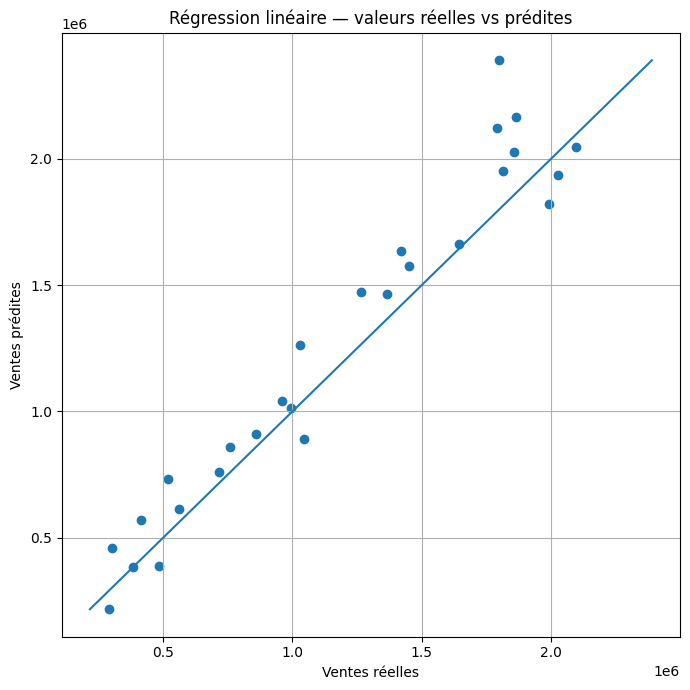

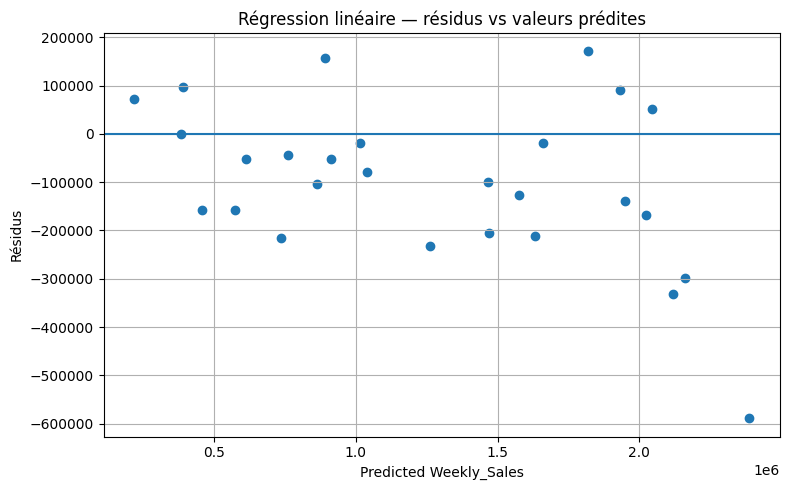

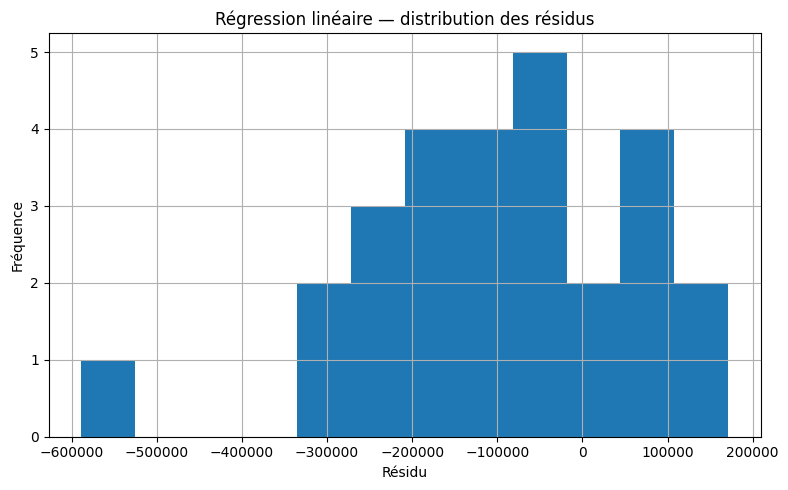

In [12]:

pred_test_linear = linear_model.predict(X_test)
residuals_linear = y_test - pred_test_linear

plt.figure(figsize=(7, 7))
plt.scatter(y_test, pred_test_linear)
lims = [
    min(y_test.min(), pred_test_linear.min()),
    max(y_test.max(), pred_test_linear.max())
]
plt.plot(lims, lims)
plt.xlabel("Ventes réelles")
plt.ylabel("Ventes prédites")
plt.title("Régression linéaire — valeurs réelles vs prédites")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(pred_test_linear, residuals_linear)
plt.axhline(0)
plt.xlabel("Predicted Weekly_Sales")
plt.ylabel("Résidus")
plt.title("Régression linéaire — résidus vs valeurs prédites")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(residuals_linear, bins=12)
plt.xlabel("Résidu")
plt.ylabel("Fréquence")
plt.title("Régression linéaire — distribution des résidus")
plt.tight_layout()
plt.show()


### Lecture de la baseline
La régression linéaire de base est déjà **solide** :
- le **R² test est proche de 0,90**, ce qui signifie que le modèle explique l'essentiel de la variance des ventes hebdomadaires ;
- le score train est meilleur que le score test, donc il existe **un certain overfitting**, mais pas à un niveau excessif ;
- les graphiques de diagnostic montrent que les prédictions suivent globalement bien les valeurs observées, avec quelques erreurs plus marquées, ce qui est normal sur un dataset aussi petit.

Cette étape est importante : avant de régulariser, il faut vérifier qu'une baseline simple est déjà crédible.


## 6. Interprétation des coefficients — qu’est-ce qui pilote les ventes hebdomadaires ?

In [13]:

feature_names = linear_model.named_steps["preprocessor"].get_feature_names_out()

linear_coefs = pd.DataFrame({
    "feature": feature_names,
    "coefficient": linear_model.named_steps["model"].coef_
})
linear_coefs["abs_coefficient"] = linear_coefs["coefficient"].abs()

top_positive = linear_coefs.sort_values("coefficient", ascending=False).head(10)
top_negative = linear_coefs.sort_values("coefficient", ascending=True).head(10)
top_numeric = (
    linear_coefs[linear_coefs["feature"].str.startswith("num__")]
    .sort_values("abs_coefficient", ascending=False)
)

print("Coefficients positifs les plus élevés")
display(top_positive[["feature", "coefficient"]].rename(columns={"feature":"variable","coefficient":"coefficient"}))

print("Coefficients négatifs les plus élevés")
display(top_negative[["feature", "coefficient"]].rename(columns={"feature":"variable","coefficient":"coefficient"}))

print("Coefficients numériques les plus importants")
display(top_numeric[["feature", "coefficient"]].rename(columns={"feature":"variable","coefficient":"coefficient"}))


Coefficients positifs les plus élevés


,variable,coefficient
11,cat__Store_14.0,"605,226.21"
2,cat__Store_4.0,"575,155.52"
17,cat__Store_20.0,"470,171.82"
10,cat__Store_13.0,"452,900.03"
8,cat__Store_10.0,"441,917.89"
0,cat__Store_2.0,"364,779.31"
24,num__Month,"67,412.15"
18,cat__Holiday_Flag_1.0,"51,506.27"
21,num__CPI,"48,864.45"
16,cat__Store_19.0,"2,823.39"


Coefficients négatifs les plus élevés


,variable,coefficient
3,cat__Store_5.0,"-1,363,365.01"
1,cat__Store_3.0,"-1,203,334.98"
13,cat__Store_16.0,"-1,155,017.00"
7,cat__Store_9.0,"-1,148,235.95"
5,cat__Store_7.0,"-969,082.08"
6,cat__Store_8.0,"-804,853.10"
12,cat__Store_15.0,"-778,867.97"
14,cat__Store_17.0,"-759,982.77"
15,cat__Store_18.0,"-285,097.74"
9,cat__Store_11.0,"-129,297.58"


Coefficients numériques les plus importants


,variable,coefficient
22,num__Unemployment,"-70,249.42"
24,num__Month,"67,412.15"
19,num__Temperature,"-60,428.22"
21,num__CPI,"48,864.45"
23,num__Year,"-47,742.14"
25,num__Day,"-15,134.58"
20,num__Fuel_Price,"-7,468.08"
26,num__DayOfWeek,0.00


### Comment interpréter correctement ces coefficients
- Les coefficients associés aux **variables indicatrices des magasins** dominent le modèle. Cela confirme que le **magasin lui-même** est un déterminant majeur du niveau de ventes.
- Parmi les variables numériques, les signaux les plus forts sont liés à **`Month`**, **`Unemployment`**, **`Temperature`**, **`Year`** et **`CPI`**.
- Comme les variables numériques ont été standardisées, leurs coefficients peuvent être comparés entre eux de façon plus pertinente.
- `DayOfWeek` est attendu comme très faible, car presque toutes les dates valides tombent le même jour de la semaine.
- Cette interprétation est utile car les modèles linéaires restent **transparents et explicables**, ce qui est intéressant dans un cadre métier.


## 7. Limiter l’overfitting — Ridge et Lasso avec GridSearchCV

In [14]:

ridge_grid = GridSearchCV(
    estimator=Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge())
    ]),
    param_grid={"model__alpha": np.logspace(-3, 4, 80)},
    cv=cv,
    scoring="neg_root_mean_squared_error"
)

lasso_grid = GridSearchCV(
    estimator=Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", Lasso(max_iter=500000))
    ]),
    param_grid={"model__alpha": np.logspace(0, 4, 80)},
    cv=cv,
    scoring="neg_root_mean_squared_error"
)

ridge_grid.fit(X_train, y_train)
lasso_grid.fit(X_train, y_train)

ridge_model = ridge_grid.best_estimator_
lasso_model = lasso_grid.best_estimator_

ridge_results = evaluate_model(
    model_name="Ridge",
    fitted_pipeline=ridge_model,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    cv_rmse_mean=-ridge_grid.best_score_,
    cv_rmse_std=np.nan,
    best_alpha=ridge_grid.best_params_["model__alpha"]
)

lasso_results = evaluate_model(
    model_name="Lasso",
    fitted_pipeline=lasso_model,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    cv_rmse_mean=-lasso_grid.best_score_,
    cv_rmse_std=np.nan,
    best_alpha=lasso_grid.best_params_["model__alpha"]
)

comparison = pd.concat([linear_results, ridge_results, lasso_results], ignore_index=True)
comparison = comparison.sort_values("test_rmse").reset_index(drop=True)

display(comparison.rename(columns=resultats_affichage).round(2))
print("Meilleur alpha Ridge :", ridge_grid.best_params_["model__alpha"])
print("Meilleur alpha Lasso :", lasso_grid.best_params_["model__alpha"])


,modele,alpha_retenu,rmse_train,rmse_test,ecart_rmse_test_moins_train,mae_train,mae_test,r2_train,r2_test,rmse_cv_moyenne,rmse_cv_ecart_type
0,Lasso,382.19,"100,585.42","185,280.31","84,694.89","76,841.21","145,196.00",0.98,0.90,"150,053.95",NaN
1,Ridge,0.03,"100,443.36","187,078.18","86,634.82","77,093.07","143,946.26",0.98,0.90,"151,079.79",NaN
2,LinearRegression,NaN,"100,070.61","188,477.53","88,406.92","77,220.08","145,802.67",0.98,0.90,"152,474.71","12,468.30"


Meilleur alpha Ridge : 0.032086999973704504
Meilleur alpha Lasso : 382.1892620633119


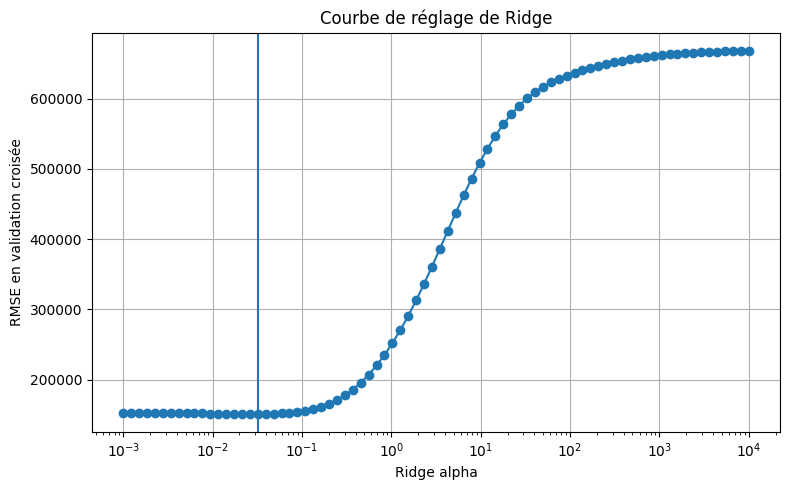

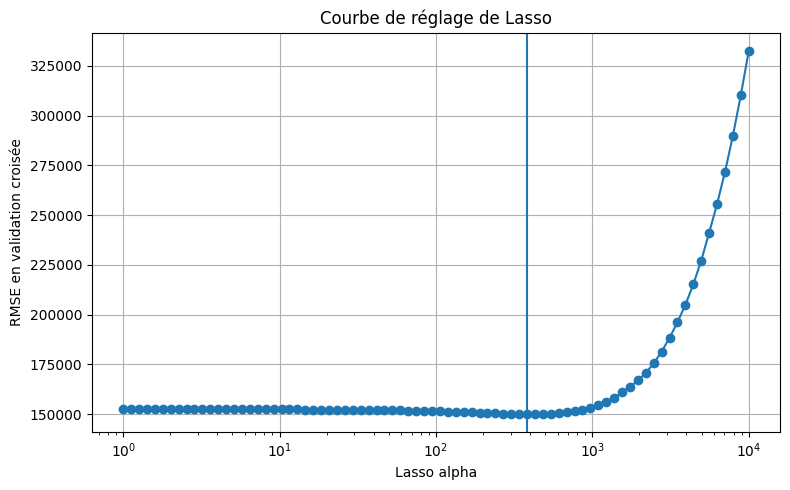

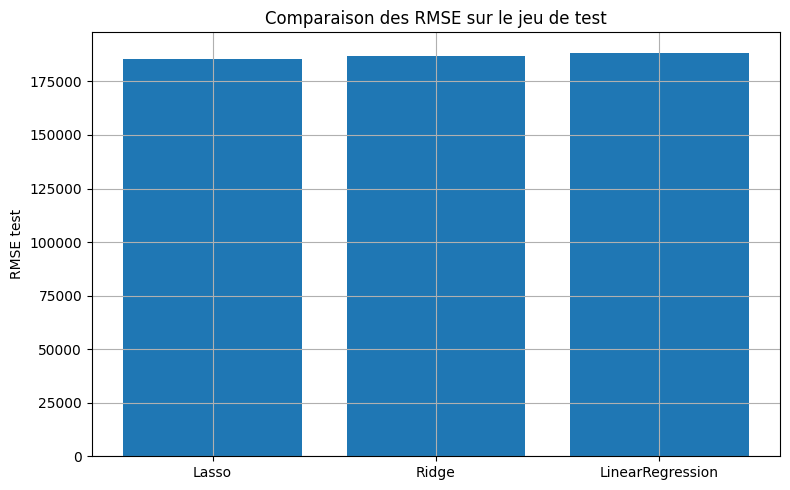

In [15]:

ridge_cv_curve = pd.DataFrame(ridge_grid.cv_results_)[["param_model__alpha", "mean_test_score"]].copy()
ridge_cv_curve["alpha"] = ridge_cv_curve["param_model__alpha"].astype(float)
ridge_cv_curve["cv_rmse"] = -ridge_cv_curve["mean_test_score"]

plt.figure(figsize=(8, 5))
plt.semilogx(ridge_cv_curve["alpha"], ridge_cv_curve["cv_rmse"], marker="o")
plt.axvline(ridge_grid.best_params_["model__alpha"])
plt.xlabel("Ridge alpha")
plt.ylabel("RMSE en validation croisée")
plt.title("Courbe de réglage de Ridge")
plt.tight_layout()
plt.show()

lasso_cv_curve = pd.DataFrame(lasso_grid.cv_results_)[["param_model__alpha", "mean_test_score"]].copy()
lasso_cv_curve["alpha"] = lasso_cv_curve["param_model__alpha"].astype(float)
lasso_cv_curve["cv_rmse"] = -lasso_cv_curve["mean_test_score"]

plt.figure(figsize=(8, 5))
plt.semilogx(lasso_cv_curve["alpha"], lasso_cv_curve["cv_rmse"], marker="o")
plt.axvline(lasso_grid.best_params_["model__alpha"])
plt.xlabel("Lasso alpha")
plt.ylabel("RMSE en validation croisée")
plt.title("Courbe de réglage de Lasso")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(comparison["model"], comparison["test_rmse"])
plt.ylabel("RMSE test")
plt.title("Comparaison des RMSE sur le jeu de test")
plt.tight_layout()
plt.show()


### Effet de la régularisation
- Le modèle linéaire de base est déjà très bon, donc les gains restent **progressifs**.
- **Ridge** améliore légèrement la généralisation en réduisant l'amplitude des coefficients sans en annuler beaucoup.
- **Lasso** obtient ici les meilleurs résultats sur l'échantillon de test et apporte un second avantage : il peut produire un **modèle plus parcimonieux** en annulant les coefficients faibles.
- Cela correspond bien à la logique du cours : utiliser la régularisation pour mieux contrôler la variance et améliorer la généralisation.


## 8. Sélection finale du modèle et diagnostics

In [16]:

final_model = lasso_model

pred_train_final = final_model.predict(X_train)
pred_test_final = final_model.predict(X_test)
residuals_final = y_test - pred_test_final

final_metrics = pd.DataFrame([{
    "modele_retenu": "Lasso",
    "alpha_retenu": lasso_grid.best_params_["model__alpha"],
    "rmse_train": rmse(y_train, pred_train_final),
    "rmse_test": rmse(y_test, pred_test_final),
    "r2_train": r2_score(y_train, pred_train_final),
    "r2_test": r2_score(y_test, pred_test_final),
    "mae_test": mean_absolute_error(y_test, pred_test_final),
    "coefficients_non_nuls": int(np.sum(final_model.named_steps["model"].coef_ != 0))
}])

display(final_metrics.round(2))


,modele_retenu,alpha_retenu,rmse_train,rmse_test,r2_train,r2_test,mae_test,coefficients_non_nuls
0,Lasso,382.19,"100,585.42","185,280.31",0.98,0.90,"145,196.00",25


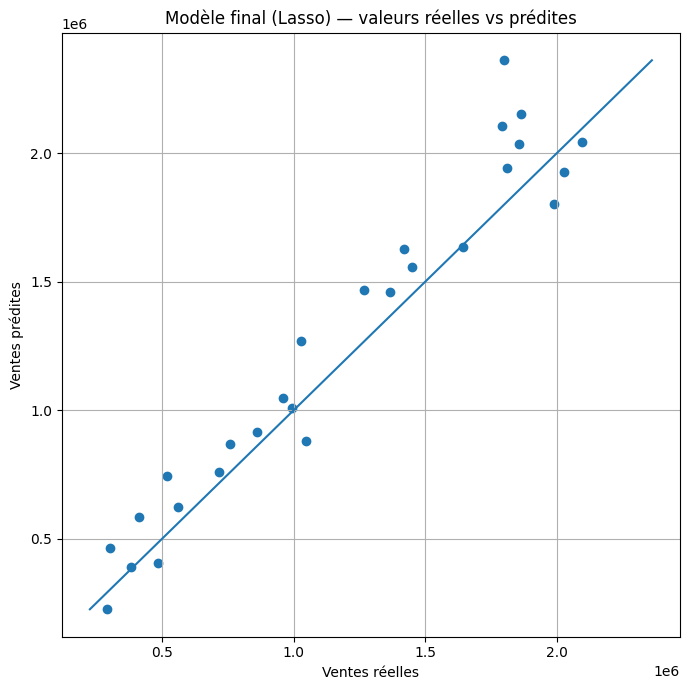

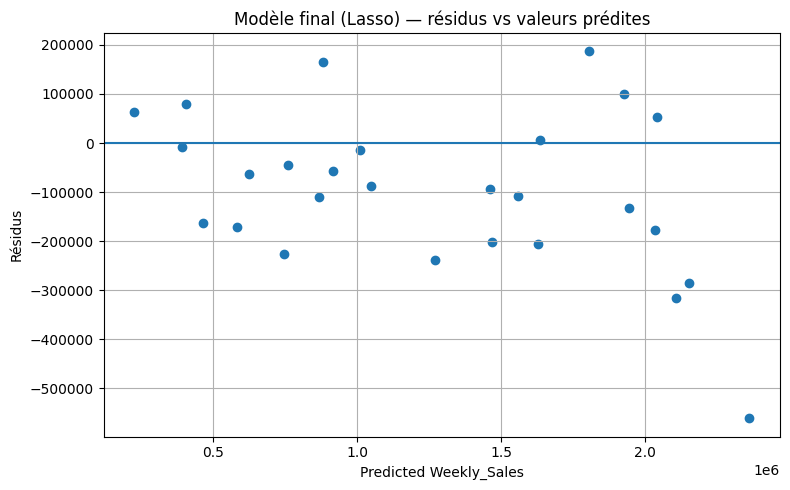

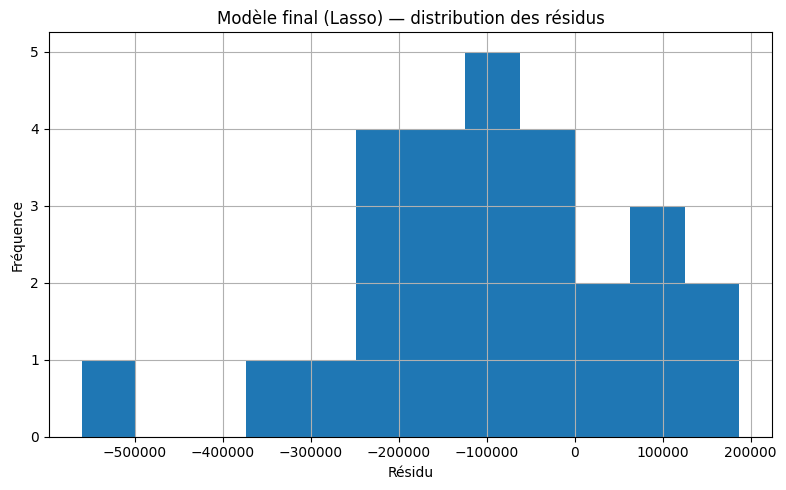

In [17]:

plt.figure(figsize=(7, 7))
plt.scatter(y_test, pred_test_final)
lims = [
    min(y_test.min(), pred_test_final.min()),
    max(y_test.max(), pred_test_final.max())
]
plt.plot(lims, lims)
plt.xlabel("Ventes réelles")
plt.ylabel("Ventes prédites")
plt.title("Modèle final (Lasso) — valeurs réelles vs prédites")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(pred_test_final, residuals_final)
plt.axhline(0)
plt.xlabel("Predicted Weekly_Sales")
plt.ylabel("Résidus")
plt.title("Modèle final (Lasso) — résidus vs valeurs prédites")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(residuals_final, bins=12)
plt.xlabel("Résidu")
plt.ylabel("Fréquence")
plt.title("Modèle final (Lasso) — distribution des résidus")
plt.tight_layout()
plt.show()


In [18]:

test_diagnostics = X_test.copy()
test_diagnostics["actual_sales"] = y_test
test_diagnostics["predicted_sales"] = pred_test_final
test_diagnostics["residual"] = y_test - pred_test_final
test_diagnostics["absolute_error"] = (y_test - pred_test_final).abs()

print("Erreurs de prédiction les plus fortes sur le jeu de test")
display(
    test_diagnostics.sort_values("absolute_error", ascending=False)
    .head(10)
    .rename(columns={
        "actual_sales": "ventes_reelles",
        "predicted_sales": "ventes_predites",
        "residual": "residu",
        "absolute_error": "erreur_absolue"
    })
)

lasso_feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()
lasso_coefs = pd.DataFrame({
    "feature": lasso_feature_names,
    "coefficient": final_model.named_steps["model"].coef_
})
lasso_coefs["abs_coefficient"] = lasso_coefs["coefficient"].abs()

print("Coefficients les plus importants du modèle final")
display(
    lasso_coefs.sort_values("abs_coefficient", ascending=False).head(15)[["feature", "coefficient"]]
    .rename(columns={"feature":"variable","coefficient":"coefficient"})
)

print("Coefficients annulés par le modèle final")
display(
    lasso_coefs[lasso_coefs["coefficient"] == 0][["feature", "coefficient"]]
    .rename(columns={"feature":"variable","coefficient":"coefficient"})
)


Erreurs de prédiction les plus fortes sur le jeu de test


,Store,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Day,DayOfWeek,ventes_reelles,ventes_predites,residu,erreur_absolue
110,20.00,1.00,28.85,3.18,204.64,7.48,"2,010.00",12.00,31.00,4.00,"1,799,737.79","2,360,615.67","-560,877.88","560,877.88"
79,20.00,0.00,69.37,NaN,NaN,7.53,"2,010.00",9.00,24.00,4.00,"1,789,687.65","2,105,357.18","-315,669.53","315,669.53"
119,14.00,0.00,34.32,3.19,182.60,NaN,"2,011.00",1.00,7.00,4.00,"1,864,746.10","2,150,674.08","-285,927.98","285,927.98"
11,18.00,0.00,52.02,2.88,132.76,9.33,"2,010.00",10.00,15.00,4.00,"1,029,618.10","1,268,928.80","-239,310.70","239,310.70"
80,9.00,0.00,49.96,2.77,215.44,6.56,"2,010.00",11.00,19.00,4.00,"519,823.30","745,216.74","-225,393.44","225,393.44"
29,6.00,0.00,NaN,3.52,217.27,6.92,"2,011.00",8.00,26.00,4.00,"1,420,405.41","1,625,870.02","-205,464.61","205,464.61"
35,19.00,0.00,33.26,3.79,133.96,7.77,"2,011.00",3.00,25.00,4.00,"1,266,564.94","1,468,960.85","-202,395.91","202,395.91"
61,10.00,0.00,57.62,3.88,130.65,7.54,"2,012.00",3.00,2.00,4.00,"1,990,371.02","1,803,160.67","187,210.35","187,210.35"
5,4.00,0.00,NaN,2.76,126.16,7.90,"2,010.00",5.00,28.00,4.00,"1,857,533.70","2,035,249.88","-177,716.18","177,716.18"
12,7.00,0.00,36.61,3.77,192.83,8.60,"2,011.00",5.00,13.00,4.00,"414,094.05","584,392.81","-170,298.76","170,298.76"


Coefficients les plus importants du modèle final


,variable,coefficient
3,cat__Store_5.0,"-1,327,822.20"
1,cat__Store_3.0,"-1,178,730.79"
13,cat__Store_16.0,"-1,118,148.35"
7,cat__Store_9.0,"-1,105,888.36"
5,cat__Store_7.0,"-954,471.05"
12,cat__Store_15.0,"-767,183.34"
6,cat__Store_8.0,"-766,441.32"
14,cat__Store_17.0,"-738,354.50"
11,cat__Store_14.0,"604,553.58"
2,cat__Store_4.0,"587,281.44"


Coefficients annulés par le modèle final


,variable,coefficient
16,cat__Store_19.0,-0.00
26,num__DayOfWeek,0.00


## 9. Conclusion métier

### Modèle retenu
Le modèle retenu est la **régression Lasso optimisée avec GridSearchCV**.

### Pourquoi ce choix est cohérent
- Il obtient le **RMSE test le plus faible** parmi les modèles évalués.
- Il améliore légèrement la baseline tout en restant entièrement dans le périmètre pédagogique du projet.
- Il simplifie aussi le modèle en annulant les coefficients les moins utiles.

### Principaux enseignements
- **L'identité du magasin** est de loin le facteur le plus déterminant des ventes hebdomadaires.
- L'information calendaire, en particulier **`Month`**, apporte également un signal utile.
- Certaines variables macroéconomiques contribuent à l'explication des ventes, notamment **`CPI`**, **`Unemployment`** et **`Temperature`**.
- `DayOfWeek` n'apporte pratiquement aucun signal, ce qui est cohérent avec la structure du dataset.

### Limites
- Le dataset est **petit**, donc les conclusions doivent rester prudentes.
- Les semaines de vacances ou de fête sont peu nombreuses.
- Certaines dates sont manquantes, ce qui réduit la richesse de l'information temporelle disponible.
- Le modèle reste **linéaire** et ne capture donc pas d'éventuels effets non linéaires plus complexes.

### Réponse à la question métier
Oui : avec les variables disponibles, il est possible de construire un modèle **fiable, interprétable et pédagogiquement cohérent** pour estimer les ventes hebdomadaires de Walmart.  
Dans ce cadre, **Lasso** constitue le meilleur compromis entre performance, simplicité et lisibilité.
